# PCA Supervised Forecasting Diagnostics

This notebook diagnoses the first supervised PCA forecasting baseline for the Polymarket crypto panel. It asks whether PCA is adding useful forecasting information beyond the raw market-implied probability, and whether the current setup is a valid benchmark before adding persistent homology.

Key leakage rule: all PCA/logistic diagnostic refits below use the same chronological folds as the supervised baseline. Imputers, scalers, PCA objects, and logistic models are fit only on each fold's training period.

In [1]:
from pathlib import Path
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import brier_score_loss, log_loss, roc_auc_score

def find_project_root(start: Path) -> Path:
    candidates = [start, *start.parents]
    for candidate in candidates:
        if (candidate / "src" / "supervised_forecasting.py").exists():
            return candidate
        nested = candidate / "polymarket_topology"
        if (nested / "src" / "supervised_forecasting.py").exists():
            return nested
    raise FileNotFoundError("Could not locate polymarket_topology project root")

ROOT = find_project_root(Path.cwd().resolve())
sys.path.append(str(ROOT / "src"))

from supervised_forecasting import (
    clean_market_universe,
    clean_panel,
    choose_component_settings,
    fit_panel_transformers,
    make_chronological_folds,
    panel_to_supervised_rows,
    pca_scores_for_setting,
    probability_clip,
)

PROCESSED = ROOT / "data" / "processed"
PLOTS = ROOT / "notebooks" / "figures" / "pca_diagnostics"
PLOTS.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)
plt.style.use("default")
warnings.filterwarnings("ignore", category=RuntimeWarning)

/Users/aaditjerfy/Documents/Playground/Topology-of-Prediction-Market-Belief-Dynamics/polymarket_topology/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


## Load Data

In [2]:
core_panel = clean_panel(pd.read_parquet(PROCESSED / "panel_hourly_core.parquet"))
core_plus_panel = clean_panel(pd.read_parquet(PROCESSED / "panel_hourly_core_plus_satellites.parquet"))
markets = clean_market_universe(pd.read_parquet(PROCESSED / "market_universe.parquet"))
results = pd.read_csv(PROCESSED / "pca_supervised_forecast_results.csv", parse_dates=["train_start", "train_end", "test_start", "test_end"])
predictions = pd.read_parquet(PROCESSED / "pca_supervised_predictions.parquet")
calibration_saved = pd.read_csv(PROCESSED / "pca_supervised_calibration_by_decile.csv")

panels = {"core": core_panel, "core_plus_satellites": core_plus_panel}
model_order = ["market_probability", "fixed_2", "fixed_5", "fixed_10", "var_85", "var_90", "var_95"]
pca_models = [m for m in model_order if m != "market_probability"]

print("core panel", core_panel.shape, core_panel.index.min(), "to", core_panel.index.max())
print("core+satellite panel", core_plus_panel.shape, core_plus_panel.index.min(), "to", core_plus_panel.index.max())
print("predictions", predictions.shape)
print("results", results.shape)

core panel (5696, 21) 2024-12-30 23:00:00+00:00 to 2026-01-01 08:00:00+00:00
core+satellite panel (5696, 30) 2024-12-30 23:00:00+00:00 to 2026-01-01 08:00:00+00:00
predictions (446339, 25)
results (98, 17)


## Helpers

In [3]:
def ece_score(df, pred_col="p_hat", y_col="Y_i", bins=10):
    d = df[[pred_col, y_col]].dropna().copy()
    d[pred_col] = probability_clip(d[pred_col])
    d["bin"] = pd.cut(d[pred_col], bins=np.linspace(0, 1, bins + 1), include_lowest=True, labels=False)
    rows = []
    total = len(d)
    for b, g in d.groupby("bin", observed=True):
        rows.append({
            "bin": int(b),
            "n_obs": len(g),
            "avg_pred": g[pred_col].mean(),
            "avg_actual": g[y_col].mean(),
            "abs_gap": abs(g[pred_col].mean() - g[y_col].mean()),
            "weight": len(g) / total if total else np.nan,
        })
    table = pd.DataFrame(rows)
    ece = float((table["weight"] * table["abs_gap"]).sum()) if not table.empty else np.nan
    return ece, table


def metric_row(df, model):
    y = df["Y_i"].astype(int).to_numpy()
    p = probability_clip(df["p_hat"])
    out = {
        "model": model,
        "n_obs": len(df),
        "yes_rate": float(np.mean(y)),
        "avg_pred": float(np.mean(p)),
        "brier": float(brier_score_loss(y, p)),
        "log_loss": float(log_loss(y, p, labels=[0, 1])),
        "ece_10": ece_score(df)[0],
    }
    try:
        out["auc"] = float(roc_auc_score(y, p)) if len(np.unique(y)) == 2 else np.nan
    except ValueError:
        out["auc"] = np.nan
    return out


def calibration_table(df):
    _, table = ece_score(df)
    return table


def add_value_labels(ax, fmt="{:.3f}"):
    for patch in ax.patches:
        height = patch.get_height()
        if np.isfinite(height):
            ax.annotate(fmt.format(height), (patch.get_x() + patch.get_width() / 2, height), ha="center", va="bottom", fontsize=8, rotation=0)


def savefig(name):
    path = PLOTS / name
    plt.tight_layout()
    plt.savefig(path, dpi=160, bbox_inches="tight")
    return path

## 1. Class Balance Analysis

We inspect class balance two ways: unique market balance and market-time row balance. The logistic objective is trained on market-time rows, so row balance is the operative balance for the supervised model.

In [4]:
panel_market_rows = []
for panel_name, panel in panels.items():
    m = markets[markets["market_id"].isin(panel.columns)].copy()
    m = m[m["Y_i"].notna()].copy()
    for _, row in m.iterrows():
        panel_market_rows.append({
            "panel": panel_name,
            "market_id": row["market_id"],
            "Y_i": int(row["Y_i"]),
            "resolved_outcome": row["resolved_outcome"],
            "market_family": row.get("market_family"),
            "asset": row.get("asset"),
            "is_core": bool(row.get("is_core", False)),
            "is_satellite": bool(row.get("is_satellite", False)),
            "question": row.get("question"),
        })
panel_markets = pd.DataFrame(panel_market_rows)

market_balance = (
    panel_markets.groupby("panel")
    .agg(markets=("market_id", "nunique"), yes_markets=("Y_i", "sum"), yes_rate=("Y_i", "mean"))
    .assign(no_rate=lambda d: 1 - d["yes_rate"])
    .reset_index()
)
row_balance = (
    predictions[predictions["model"] == "market_probability"]
    .groupby("panel")
    .agg(observations=("market_id", "size"), yes_obs=("Y_i", "sum"), yes_rate=("Y_i", "mean"))
    .assign(no_rate=lambda d: 1 - d["yes_rate"])
    .reset_index()
)

print("Unique market balance")
display(market_balance)
print("Market-time row balance")
display(row_balance)

Unique market balance


,panel,markets,yes_markets,yes_rate,no_rate
0,core,21,0,0.000000,1.000000
1,core_plus_satellites,30,1,0.033333,0.966667


Market-time row balance


,panel,observations,yes_obs,yes_rate,no_rate
0,core,38743,0,0.000000,1.000000
1,core_plus_satellites,58228,2279,0.039139,0.960861


In [5]:
family_balance = (
    panel_markets[panel_markets["panel"] == "core_plus_satellites"]
    .groupby("market_family", dropna=False)
    .agg(markets=("market_id", "nunique"), yes_markets=("Y_i", "sum"), yes_rate=("Y_i", "mean"))
    .assign(no_rate=lambda d: 1 - d["yes_rate"])
    .sort_values(["yes_rate", "markets"], ascending=[False, False])
    .reset_index()
)
core_sat_balance = (
    panel_markets[panel_markets["panel"] == "core_plus_satellites"]
    .assign(core_satellite=lambda d: np.where(d["is_core"], "core", np.where(d["is_satellite"], "satellite", "other")))
    .groupby("core_satellite")
    .agg(markets=("market_id", "nunique"), yes_markets=("Y_i", "sum"), yes_rate=("Y_i", "mean"))
    .assign(no_rate=lambda d: 1 - d["yes_rate"])
    .reset_index()
)
fold_balance = (
    predictions[(predictions["panel"] == "core_plus_satellites") & (predictions["model"] == "market_probability")]
    .groupby("fold")
    .agg(observations=("market_id", "size"), yes_obs=("Y_i", "sum"), yes_rate=("Y_i", "mean"))
    .assign(no_rate=lambda d: 1 - d["yes_rate"])
    .reset_index()
)

print("YES rate by market family - core+satellites, unique markets")
display(family_balance)
print("YES rate by fold - core+satellites, market-time rows")
display(fold_balance)
print("YES rate by core vs satellite - core+satellites, unique markets")
display(core_sat_balance)

YES rate by market family - core+satellites, unique markets


,market_family,markets,yes_markets,yes_rate,no_rate
0,crypto_policy,8,1,0.125,0.875
1,btc_price,14,0,0.000,1.000
2,eth_price,7,0,0.000,1.000
3,microstrategy,1,0,0.000,1.000


YES rate by fold - core+satellites, market-time rows


,fold,observations,yes_obs,yes_rate,no_rate
0,1,8736,336,0.038462,0.961538
1,2,8736,336,0.038462,0.961538
2,3,8736,336,0.038462,0.961538
3,4,8736,336,0.038462,0.961538
4,5,8736,336,0.038462,0.961538
5,6,8236,336,0.040797,0.959203
6,7,6312,263,0.041667,0.958333


YES rate by core vs satellite - core+satellites, unique markets


,core_satellite,markets,yes_markets,yes_rate,no_rate
0,core,21,0,0.000000,1.000000
1,satellite,9,1,0.111111,0.888889


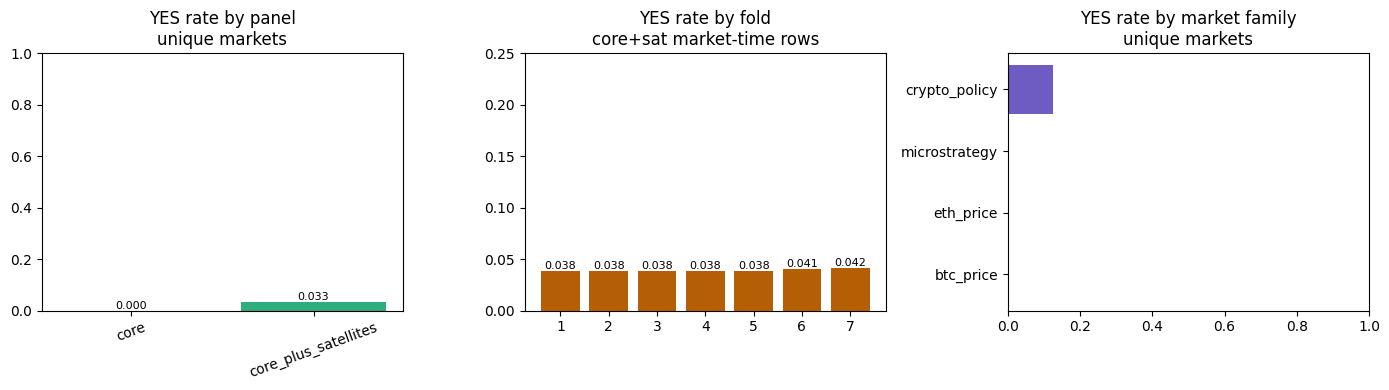

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].bar(market_balance["panel"], market_balance["yes_rate"], color=["#5B8DEF", "#2EAD7D"])
axes[0].set_title("YES rate by panel\nunique markets")
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis="x", rotation=20)
add_value_labels(axes[0])

axes[1].bar(fold_balance["fold"].astype(str), fold_balance["yes_rate"], color="#B45F06")
axes[1].set_title("YES rate by fold\ncore+sat market-time rows")
axes[1].set_ylim(0, max(0.25, fold_balance["yes_rate"].max() * 1.25))
add_value_labels(axes[1])

plot_family = family_balance.sort_values("yes_rate", ascending=True)
axes[2].barh(plot_family["market_family"].astype(str), plot_family["yes_rate"], color="#6F5CC2")
axes[2].set_title("YES rate by market family\nunique markets")
axes[2].set_xlim(0, 1)

class_balance_plot = savefig("01_class_balance.png")
plt.show()

## 2. Baseline Calibration Analysis

The raw market baseline is `p_hat = p_i,t`. It is evaluated only on future test rows from the chronological folds.

In [7]:
baseline = predictions[(predictions["panel"] == "core_plus_satellites") & (predictions["model"] == "market_probability")].copy()
baseline_metrics = pd.DataFrame([metric_row(baseline, "market_probability")])
baseline_cal = calibration_table(baseline)

print("Baseline metrics - core+satellites")
display(baseline_metrics)
print("Baseline calibration by decile")
display(baseline_cal)

Baseline metrics - core+satellites


,model,n_obs,yes_rate,avg_pred,brier,log_loss,ece_10,auc
0,market_probability,58228,0.039139,0.059757,0.040993,0.13199,0.052254,0.916638


Baseline calibration by decile


,bin,n_obs,avg_pred,avg_actual,abs_gap,weight
0,0,48142,0.018569,0.001516,0.017053,0.826784
1,1,5425,0.146348,0.316129,0.169781,0.093168
2,2,1907,0.242136,0.145254,0.096881,0.032751
3,3,941,0.348160,0.194474,0.153686,0.016161
4,4,857,0.449814,0.036173,0.413642,0.014718
5,5,459,0.544968,0.000000,0.544968,0.007883
6,6,157,0.654860,0.000000,0.654860,0.002696
7,7,250,0.751924,0.000000,0.751924,0.004293
8,8,90,0.842467,0.000000,0.842467,0.001546


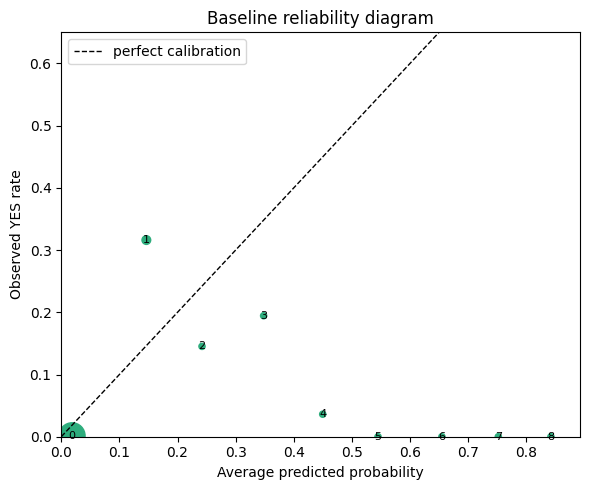

In [8]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot([0, 1], [0, 1], color="black", linewidth=1, linestyle="--", label="perfect calibration")
ax.scatter(baseline_cal["avg_pred"], baseline_cal["avg_actual"], s=np.maximum(20, baseline_cal["n_obs"] / baseline_cal["n_obs"].max() * 350), color="#2EAD7D")
for _, r in baseline_cal.iterrows():
    ax.text(r["avg_pred"], r["avg_actual"], str(int(r["bin"])), fontsize=8, ha="center", va="center")
ax.set_title("Baseline reliability diagram")
ax.set_xlabel("Average predicted probability")
ax.set_ylabel("Observed YES rate")
ax.set_xlim(0, max(0.65, baseline_cal["avg_pred"].max() + 0.05))
ax.set_ylim(0, max(0.65, baseline_cal["avg_actual"].max() + 0.05))
ax.legend()
baseline_reliability_plot = savefig("02_baseline_reliability.png")
plt.show()

## 3. PCA Logistic Calibration Analysis

We repeat the calibration diagnostics for all PCA logistic configurations and compare against raw market probabilities.

In [9]:
metric_rows = []
for model in model_order:
    df = predictions[(predictions["panel"] == "core_plus_satellites") & (predictions["model"] == model)].copy()
    if df.empty:
        continue
    metric_rows.append(metric_row(df, model))
metrics_by_model = pd.DataFrame(metric_rows)
metrics_by_model["brier_delta_vs_baseline"] = metrics_by_model["brier"] - float(baseline_metrics.loc[0, "brier"])
metrics_by_model["log_loss_delta_vs_baseline"] = metrics_by_model["log_loss"] - float(baseline_metrics.loc[0, "log_loss"])
metrics_by_model["ece_delta_vs_baseline"] = metrics_by_model["ece_10"] - float(baseline_metrics.loc[0, "ece_10"])
metrics_by_model = metrics_by_model.set_index("model").loc[[m for m in model_order if m in metrics_by_model["model"].values]].reset_index()
display(metrics_by_model)

,model,n_obs,yes_rate,avg_pred,brier,log_loss,ece_10,auc,brier_delta_vs_baseline,log_loss_delta_vs_baseline,ece_delta_vs_baseline
0,market_probability,58228,0.039139,0.059757,0.040993,0.131990,0.052254,0.916638,0.000000,0.000000,0.000000
1,fixed_2,58228,0.039139,0.035079,0.037025,0.158420,0.004125,0.699513,-0.003967,0.026429,-0.048129
2,fixed_5,58228,0.039139,0.038705,0.037111,0.158657,0.000970,0.731121,-0.003882,0.026667,-0.051283
3,fixed_10,58228,0.039139,0.042490,0.037218,0.160023,0.003351,0.659418,-0.003775,0.028033,-0.048903
4,var_85,58228,0.039139,0.037907,0.037079,0.158430,0.001477,0.728182,-0.003914,0.026439,-0.050777
5,var_90,58228,0.039139,0.038938,0.037058,0.158326,0.000372,0.723806,-0.003934,0.026335,-0.051881
6,var_95,58228,0.039139,0.042532,0.037212,0.159963,0.003393,0.661671,-0.003781,0.027973,-0.048861


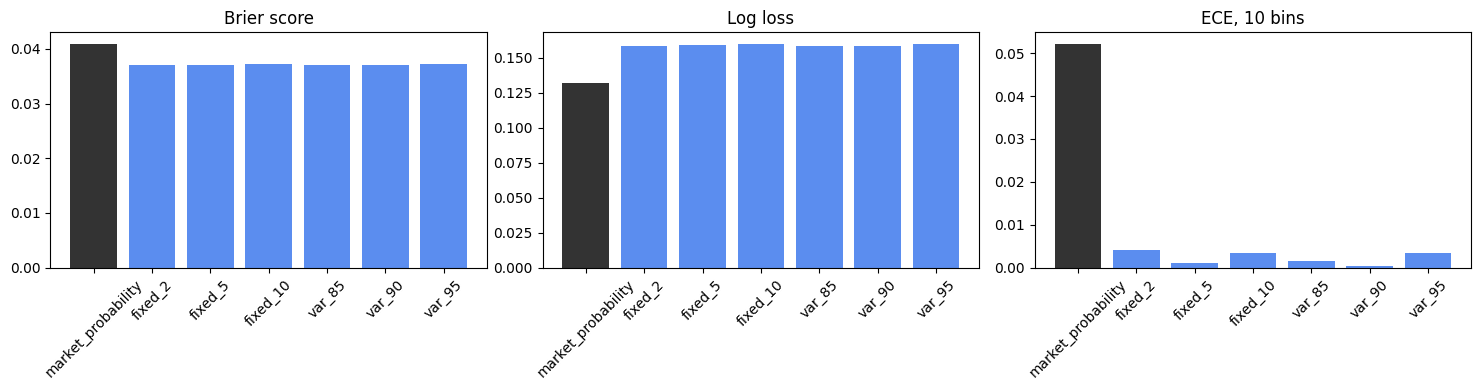

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
plot_df = metrics_by_model.copy()
colors = ["#333333" if m == "market_probability" else "#5B8DEF" for m in plot_df["model"]]
axes[0].bar(plot_df["model"], plot_df["brier"], color=colors)
axes[0].set_title("Brier score")
axes[0].tick_params(axis="x", rotation=45)
axes[1].bar(plot_df["model"], plot_df["log_loss"], color=colors)
axes[1].set_title("Log loss")
axes[1].tick_params(axis="x", rotation=45)
axes[2].bar(plot_df["model"], plot_df["ece_10"], color=colors)
axes[2].set_title("ECE, 10 bins")
axes[2].tick_params(axis="x", rotation=45)
metrics_plot = savefig("03_model_metric_comparison.png")
plt.show()

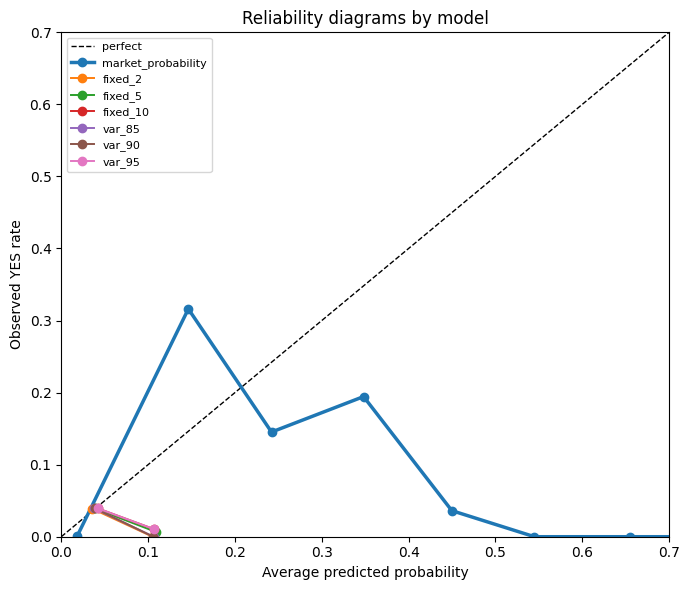

,bin,n_obs,avg_pred,avg_actual,abs_gap,weight,model
0,0,48142,0.018569,0.001516,0.017053,0.826784,market_probability
1,1,5425,0.146348,0.316129,0.169781,0.093168,market_probability
2,2,1907,0.242136,0.145254,0.096881,0.032751,market_probability
3,3,941,0.348160,0.194474,0.153686,0.016161,market_probability
4,4,857,0.449814,0.036173,0.413642,0.014718,market_probability
5,5,459,0.544968,0.000000,0.544968,0.007883,market_probability
6,6,157,0.654860,0.000000,0.654860,0.002696,market_probability
7,7,250,0.751924,0.000000,0.751924,0.004293,market_probability
8,8,90,0.842467,0.000000,0.842467,0.001546,market_probability
9,0,58210,0.035058,0.039151,0.004094,0.999691,fixed_2


In [11]:
calibration_tables = []
for model in model_order:
    df = predictions[(predictions["panel"] == "core_plus_satellites") & (predictions["model"] == model)]
    if df.empty:
        continue
    t = calibration_table(df)
    t["model"] = model
    calibration_tables.append(t)
calibration_all = pd.concat(calibration_tables, ignore_index=True)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot([0, 1], [0, 1], color="black", linewidth=1, linestyle="--", label="perfect")
for model in model_order:
    t = calibration_all[calibration_all["model"] == model]
    if t.empty:
        continue
    lw = 2.5 if model == "market_probability" else 1.4
    ax.plot(t["avg_pred"], t["avg_actual"], marker="o", linewidth=lw, label=model)
ax.set_title("Reliability diagrams by model")
ax.set_xlabel("Average predicted probability")
ax.set_ylabel("Observed YES rate")
ax.set_xlim(0, 0.7)
ax.set_ylim(0, 0.7)
ax.legend(fontsize=8)
all_reliability_plot = savefig("04_all_reliability.png")
plt.show()

display(calibration_all.head(30))

In [12]:
tail_rows = []
for model in model_order:
    df = predictions[(predictions["panel"] == "core_plus_satellites") & (predictions["model"] == model)].copy()
    if df.empty:
        continue
    y0 = df[df["Y_i"] == 0]["p_hat"]
    y1 = df[df["Y_i"] == 1]["p_hat"]
    tail_rows.append({
        "model": model,
        "mean_pred_on_NO": y0.mean(),
        "p95_pred_on_NO": y0.quantile(0.95),
        "max_pred_on_NO": y0.max(),
        "mean_pred_on_YES": y1.mean(),
        "p05_pred_on_YES": y1.quantile(0.05),
        "min_pred_on_YES": y1.min(),
    })
tail_diagnostics = pd.DataFrame(tail_rows)
display(tail_diagnostics)

,model,mean_pred_on_NO,p95_pred_on_NO,max_pred_on_NO,mean_pred_on_YES,p05_pred_on_YES,min_pred_on_YES
0,market_probability,0.054451,0.280000,0.885000,0.190000,0.110000,0.055000
1,fixed_2,0.034714,0.054808,0.111609,0.044053,0.026751,0.016074
2,fixed_5,0.038355,0.067952,0.135815,0.047299,0.029172,0.019773
3,fixed_10,0.042148,0.072301,0.123510,0.050891,0.029846,0.022139
4,var_85,0.037557,0.062580,0.125136,0.046501,0.029255,0.020033
5,var_90,0.038581,0.061739,0.122055,0.047712,0.030639,0.022716
6,var_95,0.042188,0.072301,0.123510,0.050988,0.030121,0.022323


## 4. Feature Importance Analysis

We refit the fold-specific logistic PCA models and report raw coefficients plus standardized effects. The standardized effect is `coefficient * training_feature_standard_deviation`, i.e. approximate log-odds movement for a one-standard-deviation feature move in the training rows.

In [13]:
def collect_fold_model_diagnostics(panel, markets, panel_name="core_plus_satellites"):
    panel = clean_panel(panel)
    markets = clean_market_universe(markets)
    markets = markets[markets["market_id"].isin(panel.columns)].copy()
    folds = make_chronological_folds(panel)
    coef_rows = []
    loading_rows = []
    explained_rows = []

    for fold in folds:
        train_panel = panel.loc[fold.train_start:fold.train_end]
        imputer, scaler, train_scaled, pca_feature_cols = fit_panel_transformers(train_panel)
        all_scaled = scaler.transform(imputer.transform(panel[pca_feature_cols]))
        settings = choose_component_settings(train_scaled, len(pca_feature_cols))

        for model_name, n_components in sorted(settings.items(), key=lambda item: (item[1], item[0])):
            scores, pca = pca_scores_for_setting(train_scaled, all_scaled, n_components=n_components)
            pca_cols = [f"pca_{idx + 1}" for idx in range(n_components)]
            pca_frame = pd.DataFrame(scores, index=panel.index, columns=pca_cols)
            panel_with_pca = panel.join(pca_frame)
            train_rows = panel_to_supervised_rows(panel_with_pca, markets, fold, split="train", known_labels_only=False)
            test_rows = panel_to_supervised_rows(panel_with_pca, markets, fold, split="test", known_labels_only=False)
            if train_rows.empty or test_rows.empty or train_rows["Y_i"].nunique() < 2:
                continue

            feature_cols = ["p_i_t", *pca_cols]
            train_x = train_rows[feature_cols].astype(float)
            model = LogisticRegression(penalty="l2", C=1.0, solver="lbfgs", max_iter=1000, class_weight=None, random_state=0)
            model.fit(train_x, train_rows["Y_i"].astype(int))
            train_std = train_x.std(axis=0, ddof=0).replace(0, np.nan)
            for feature, coef in zip(feature_cols, model.coef_[0]):
                coef_rows.append({
                    "panel": panel_name,
                    "fold": fold.fold,
                    "model": model_name,
                    "n_components": n_components,
                    "feature": feature,
                    "coefficient": float(coef),
                    "abs_coefficient": float(abs(coef)),
                    "feature_train_std": float(train_std[feature]),
                    "standardized_effect": float(coef * train_std[feature]),
                    "abs_standardized_effect": float(abs(coef * train_std[feature])),
                    "intercept": float(model.intercept_[0]),
                    "train_rows": len(train_rows),
                    "train_yes_rate": float(train_rows["Y_i"].mean()),
                })

            for comp_idx, ratio in enumerate(pca.explained_variance_ratio_, start=1):
                explained_rows.append({
                    "panel": panel_name,
                    "fold": fold.fold,
                    "model": model_name,
                    "n_components": n_components,
                    "component": f"pca_{comp_idx}",
                    "explained_variance_ratio": float(ratio),
                    "cumulative_explained_variance": float(np.sum(pca.explained_variance_ratio_[:comp_idx])),
                })
            for comp_idx, component in enumerate(pca.components_, start=1):
                for market_id, loading in zip(pca_feature_cols, component):
                    loading_rows.append({
                        "panel": panel_name,
                        "fold": fold.fold,
                        "model": model_name,
                        "n_components": n_components,
                        "component": f"pca_{comp_idx}",
                        "market_id": market_id,
                        "loading": float(loading),
                        "abs_loading": float(abs(loading)),
                    })
    return pd.DataFrame(coef_rows), pd.DataFrame(explained_rows), pd.DataFrame(loading_rows)

coef_df, explained_df, loadings_df = collect_fold_model_diagnostics(core_plus_panel, markets)
print(coef_df.shape, explained_df.shape, loadings_df.shape)
display(coef_df.head())

(314, 13) (272, 7) (8160, 8)


,panel,fold,model,n_components,feature,coefficient,abs_coefficient,feature_train_std,standardized_effect,abs_standardized_effect,intercept,train_rows,train_yes_rate
0,core_plus_satellites,1,fixed_2,2,p_i_t,0.434905,0.434905,0.194105,0.084417,0.084417,-6.213387,79140,0.015454
1,core_plus_satellites,1,fixed_2,2,pca_1,-0.685212,0.685212,3.384013,-2.318764,2.318764,-6.213387,79140,0.015454
2,core_plus_satellites,1,fixed_2,2,pca_2,-0.086166,0.086166,2.809478,-0.242082,0.242082,-6.213387,79140,0.015454
3,core_plus_satellites,1,fixed_5,5,p_i_t,0.497155,0.497155,0.194105,0.096500,0.096500,-6.699851,79140,0.015454
4,core_plus_satellites,1,fixed_5,5,pca_1,-0.682176,0.682176,3.384013,-2.308491,2.308491,-6.699851,79140,0.015454


In [14]:
coef_summary = (
    coef_df.groupby(["model", "feature"])
    .agg(
        mean_coef=("coefficient", "mean"),
        mean_abs_coef=("abs_coefficient", "mean"),
        mean_standardized_effect=("standardized_effect", "mean"),
        mean_abs_standardized_effect=("abs_standardized_effect", "mean"),
        folds=("fold", "nunique"),
    )
    .reset_index()
)
pit_summary = coef_summary[coef_summary["feature"] == "p_i_t"].sort_values("model")
pca_coef_summary = (
    coef_summary[coef_summary["feature"].str.startswith("pca_")]
    .groupby("model")
    .agg(
        mean_abs_pca_standardized_effect=("mean_abs_standardized_effect", "mean"),
        max_abs_pca_standardized_effect=("mean_abs_standardized_effect", "max"),
        pca_features=("feature", "nunique"),
    )
    .reset_index()
)
importance_compare = pit_summary[["model", "mean_standardized_effect", "mean_abs_standardized_effect"]].rename(columns={
    "mean_standardized_effect": "p_i_t_mean_standardized_effect",
    "mean_abs_standardized_effect": "p_i_t_abs_standardized_effect",
}).merge(pca_coef_summary, on="model", how="left")
importance_compare["p_i_t_to_mean_pca_abs_ratio"] = importance_compare["p_i_t_abs_standardized_effect"] / importance_compare["mean_abs_pca_standardized_effect"]

print("Current market probability coefficient summary")
display(pit_summary)
print("p_i_t vs PCA standardized-effect comparison")
display(importance_compare)
print("Top standardized coefficients")
display(coef_summary.sort_values("mean_abs_standardized_effect", ascending=False).head(25))

Current market probability coefficient summary


,model,feature,mean_coef,mean_abs_coef,mean_standardized_effect,mean_abs_standardized_effect,folds
0,fixed_10,p_i_t,1.378263,1.378263,0.254988,0.254988,7
11,fixed_2,p_i_t,1.333696,1.333696,0.246591,0.246591,7
14,fixed_5,p_i_t,1.370537,1.370537,0.253563,0.253563,7
20,var_85,p_i_t,1.372238,1.372238,0.253886,0.253886,7
27,var_90,p_i_t,1.375485,1.375485,0.254455,0.254455,7
36,var_95,p_i_t,1.381565,1.381565,0.255584,0.255584,7


p_i_t vs PCA standardized-effect comparison


,model,p_i_t_mean_standardized_effect,p_i_t_abs_standardized_effect,mean_abs_pca_standardized_effect,max_abs_pca_standardized_effect,pca_features,p_i_t_to_mean_pca_abs_ratio
0,fixed_10,0.254988,0.254988,0.449313,2.288598,10,0.567507
1,fixed_2,0.246591,0.246591,1.398003,1.942073,2,0.176388
2,fixed_5,0.253563,0.253563,0.698457,2.044762,5,0.363033
3,var_85,0.253886,0.253886,0.604566,2.060281,6,0.419948
4,var_90,0.254455,0.254455,0.464777,2.064266,8,0.547477
5,var_95,0.255584,0.255584,0.451202,2.273664,10,0.566450


Top standardized coefficients


,model,feature,mean_coef,mean_abs_coef,mean_standardized_effect,mean_abs_standardized_effect,folds
1,fixed_10,pca_1,-0.669959,0.669959,-2.288598,2.288598,7
37,var_95,pca_1,-0.665804,0.665804,-2.273664,2.273664,7
28,var_90,pca_1,-0.603394,0.603394,-2.064266,2.064266,7
21,var_85,pca_1,-0.602242,0.602242,-2.060281,2.060281,7
15,fixed_5,pca_1,-0.597530,0.597530,-2.044762,2.044762,7
12,fixed_2,pca_1,-0.567370,0.567370,-1.942073,1.942073,7
39,var_95,pca_2,0.132535,0.412444,0.359534,1.144902,7
3,fixed_10,pca_2,0.124003,0.403912,0.336070,1.121438,7
29,var_90,pca_2,0.160038,0.353980,0.438629,0.981601,7
22,var_85,pca_2,0.133509,0.339138,0.363429,0.939682,7


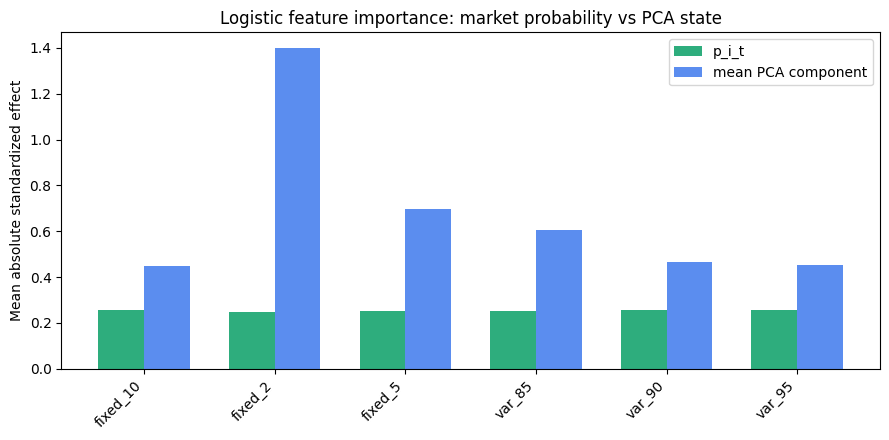

In [15]:
fig, ax = plt.subplots(figsize=(9, 4.5))
plot_imp = importance_compare.sort_values("model")
x = np.arange(len(plot_imp))
width = 0.35
ax.bar(x - width/2, plot_imp["p_i_t_abs_standardized_effect"], width, label="p_i_t", color="#2EAD7D")
ax.bar(x + width/2, plot_imp["mean_abs_pca_standardized_effect"], width, label="mean PCA component", color="#5B8DEF")
ax.set_xticks(x)
ax.set_xticklabels(plot_imp["model"], rotation=45, ha="right")
ax.set_ylabel("Mean absolute standardized effect")
ax.set_title("Logistic feature importance: market probability vs PCA state")
ax.legend()
importance_plot = savefig("05_feature_importance.png")
plt.show()

## 5. PCA Information Content Analysis

We inspect explained variance and loadings. Loadings identify which markets dominate each component. Because PCA is refit separately in each chronological fold, the tables below aggregate by average absolute loading across folds.

,model,component,mean_explained_variance_ratio,mean_cumulative_explained_variance,folds
0,fixed_10,pca_1,0.391867,0.391867,7
1,fixed_10,pca_10,0.011030,0.960968,7
2,fixed_10,pca_2,0.264631,0.656498,7
3,fixed_10,pca_3,0.118377,0.774875,7
4,fixed_10,pca_4,0.045254,0.820130,7
5,fixed_10,pca_5,0.034120,0.854249,7
6,fixed_10,pca_6,0.031561,0.885810,7
7,fixed_10,pca_7,0.028801,0.914612,7
8,fixed_10,pca_8,0.020327,0.934938,7
9,fixed_10,pca_9,0.015000,0.949938,7


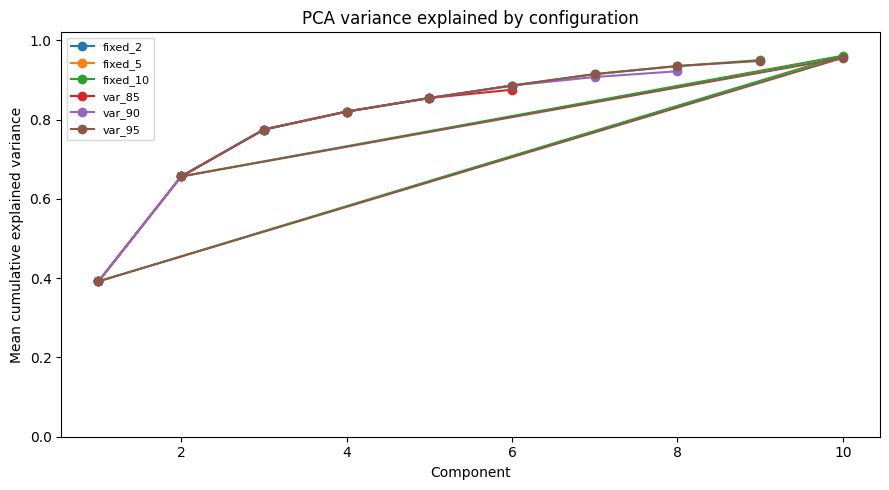

In [16]:
explained_summary = (
    explained_df.groupby(["model", "component"])
    .agg(
        mean_explained_variance_ratio=("explained_variance_ratio", "mean"),
        mean_cumulative_explained_variance=("cumulative_explained_variance", "mean"),
        folds=("fold", "nunique"),
    )
    .reset_index()
)
display(explained_summary.head(40))

fig, ax = plt.subplots(figsize=(9, 5))
for model in pca_models:
    t = explained_summary[explained_summary["model"] == model].copy()
    if t.empty:
        continue
    t["component_num"] = t["component"].str.replace("pca_", "", regex=False).astype(int)
    ax.plot(t["component_num"], t["mean_cumulative_explained_variance"], marker="o", label=model)
ax.set_ylim(0, 1.02)
ax.set_xlabel("Component")
ax.set_ylabel("Mean cumulative explained variance")
ax.set_title("PCA variance explained by configuration")
ax.legend(fontsize=8)
variance_plot = savefig("06_pca_variance_explained.png")
plt.show()

In [17]:
market_lookup = markets[["market_id", "question", "market_family", "asset", "is_core", "is_satellite"]].copy()
loadings_named = loadings_df.merge(market_lookup, on="market_id", how="left")
loading_dominance = (
    loadings_named.groupby(["model", "component", "market_id", "question", "market_family", "asset", "is_core", "is_satellite"], dropna=False)
    .agg(mean_loading=("loading", "mean"), mean_abs_loading=("abs_loading", "mean"))
    .reset_index()
)

top_loadings = (
    loading_dominance.sort_values(["model", "component", "mean_abs_loading"], ascending=[True, True, False])
    .groupby(["model", "component"], as_index=False)
    .head(5)
)
display(top_loadings.head(60))

,model,component,market_id,question,market_family,asset,is_core,is_satellite,mean_loading,mean_abs_loading
13,fixed_10,pca_1,516873,"Will Bitcoin dip to $20,000 by December 31, 2025?",btc_price,BTC,True,False,0.258667,0.258667
19,fixed_10,pca_1,516926,MicroStrategy sells any Bitcoin in 2025?,microstrategy,MSTR,False,True,0.258036,0.258036
7,fixed_10,pca_1,516862,"Will Bitcoin reach $250,000 by December 31, 2025?",btc_price,BTC,True,False,0.252090,0.252090
20,fixed_10,pca_1,516937,US national Bitcoin reserve in 2025?,crypto_policy,NaN,False,True,0.251961,0.251961
12,fixed_10,pca_1,516872,"Will Bitcoin dip to $50,000 by December 31, 2025?",btc_price,BTC,True,False,0.247663,0.247663
56,fixed_10,pca_10,574071,"Will Ethereum hit $14,000 by December 31?",eth_price,ETH,True,False,0.274859,0.368615
54,fixed_10,pca_10,572479,Will Trump nominate Ron Paul as the next Fed c...,crypto_policy,NaN,False,True,0.239333,0.312264
53,fixed_10,pca_10,572477,Will Trump nominate Larry Kudlow as the next F...,crypto_policy,NaN,False,True,-0.129245,0.257094
34,fixed_10,pca_10,516729,Will 8+ Fed rate cuts happen in 2025?,crypto_policy,NaN,False,True,0.179083,0.247266
50,fixed_10,pca_10,516937,US national Bitcoin reserve in 2025?,crypto_policy,NaN,False,True,0.165153,0.229521


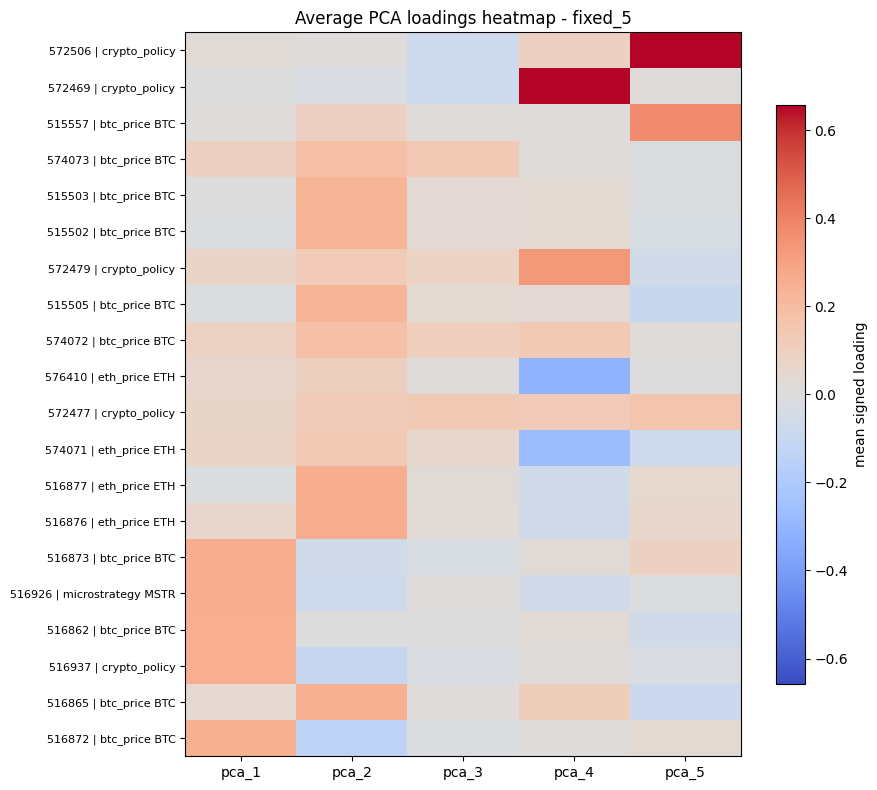

In [18]:
# Heatmap for fixed_5, using average signed loadings across folds.
heat_model = "fixed_5"
heat = loading_dominance[loading_dominance["model"] == heat_model].copy()
heat["component_num"] = heat["component"].str.replace("pca_", "", regex=False).astype(int)
# Keep markets that are large in at least one component.
top_markets = (
    heat.groupby("market_id")["mean_abs_loading"].max().sort_values(ascending=False).head(20).index.tolist()
)
heat_matrix = (
    heat[heat["market_id"].isin(top_markets)]
    .pivot_table(index="market_id", columns="component", values="mean_loading", aggfunc="mean")
    .reindex(index=top_markets)
)
labels = []
for mid in heat_matrix.index:
    row = market_lookup[market_lookup["market_id"] == mid].iloc[0]
    fam = row.get("market_family") or "unknown"
    asset = row.get("asset") or ""
    labels.append(f"{mid} | {fam} {asset}".strip())

fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(heat_matrix.to_numpy(), aspect="auto", cmap="coolwarm", vmin=-np.nanmax(abs(heat_matrix.to_numpy())), vmax=np.nanmax(abs(heat_matrix.to_numpy())))
ax.set_xticks(np.arange(len(heat_matrix.columns)))
ax.set_xticklabels(heat_matrix.columns)
ax.set_yticks(np.arange(len(heat_matrix.index)))
ax.set_yticklabels(labels, fontsize=8)
ax.set_title("Average PCA loadings heatmap - fixed_5")
plt.colorbar(im, ax=ax, shrink=0.8, label="mean signed loading")
loadings_heatmap = savefig("07_fixed5_loading_heatmap.png")
plt.show()

## 6. Forecasting Decomposition By Fold

We compare each PCA logistic model to the raw market-probability baseline within the same chronological fold.

In [19]:
ok_results = results[(results["panel"] == "core_plus_satellites") & (results["status"] == "ok")].copy()
base_by_fold = ok_results[ok_results["model"] == "market_probability"][["fold", "brier", "log_loss", "avg_pred", "avg_actual"]].rename(columns={
    "brier": "baseline_brier",
    "log_loss": "baseline_log_loss",
    "avg_pred": "baseline_avg_pred",
    "avg_actual": "baseline_avg_actual",
})
fold_decomp = ok_results[ok_results["model"] != "market_probability"].merge(base_by_fold, on="fold", how="left")
fold_decomp["brier_improvement"] = fold_decomp["baseline_brier"] - fold_decomp["brier"]
fold_decomp["log_loss_improvement"] = fold_decomp["baseline_log_loss"] - fold_decomp["log_loss"]
fold_decomp["avg_pred_shift"] = fold_decomp["avg_pred"] - fold_decomp["baseline_avg_pred"]
fold_decomp["calibration_shift_abs"] = abs(fold_decomp["avg_pred"] - fold_decomp["avg_actual"]) - abs(fold_decomp["baseline_avg_pred"] - fold_decomp["baseline_avg_actual"])

display(fold_decomp[["fold", "model", "n_obs", "brier_improvement", "log_loss_improvement", "avg_pred_shift", "calibration_shift_abs"]].head(60))

fold_summary = (
    fold_decomp.groupby("model")
    .agg(
        folds=("fold", "nunique"),
        brier_helped_folds=("brier_improvement", lambda s: int((s > 0).sum())),
        log_loss_helped_folds=("log_loss_improvement", lambda s: int((s > 0).sum())),
        mean_brier_improvement=("brier_improvement", "mean"),
        mean_log_loss_improvement=("log_loss_improvement", "mean"),
        mean_calibration_shift_abs=("calibration_shift_abs", "mean"),
    )
    .reset_index()
)
display(fold_summary)

,fold,model,n_obs,brier_improvement,log_loss_improvement,avg_pred_shift,calibration_shift_abs
0,1,fixed_2,8736,0.043555,0.083082,-0.091874,-0.091874
1,1,fixed_5,8736,0.043119,0.079787,-0.078452,-0.078452
2,1,var_85,8736,0.043367,0.081706,-0.083285,-0.083285
3,1,var_90,8736,0.043419,0.082111,-0.084336,-0.084336
4,1,fixed_10,8736,0.043251,0.080700,-0.079881,-0.079881
5,1,var_95,8736,0.043251,0.080700,-0.079881,-0.079881
6,2,fixed_2,8736,0.016206,0.019899,-0.070573,-0.056263
7,2,fixed_5,8736,0.016239,0.020415,-0.069355,-0.057482
8,2,var_85,8736,0.016224,0.020217,-0.070549,-0.056288
9,2,var_90,8736,0.016227,0.020253,-0.070169,-0.056668


,model,folds,brier_helped_folds,log_loss_helped_folds,mean_brier_improvement,mean_log_loss_improvement,mean_calibration_shift_abs
0,fixed_10,7,3,2,0.002891,-0.030924,-0.027777
1,fixed_2,7,3,2,0.003076,-0.029357,-0.031535
2,fixed_5,7,3,2,0.002991,-0.029590,-0.030079
3,var_85,7,3,2,0.003022,-0.029373,-0.030457
4,var_90,7,3,2,0.003043,-0.029269,-0.030752
5,var_95,7,3,2,0.002897,-0.030858,-0.027829


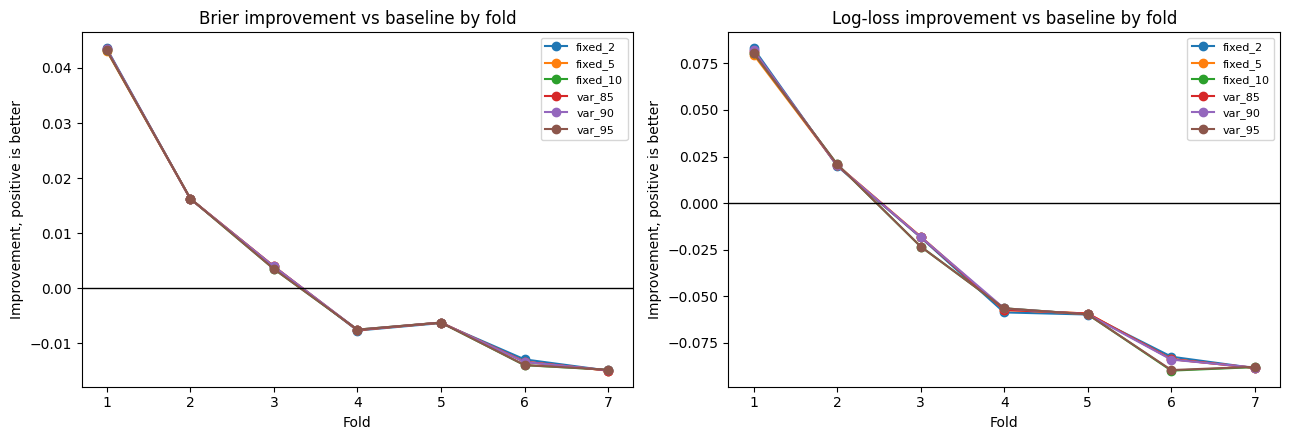

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for model in pca_models:
    t = fold_decomp[fold_decomp["model"] == model]
    axes[0].plot(t["fold"], t["brier_improvement"], marker="o", label=model)
    axes[1].plot(t["fold"], t["log_loss_improvement"], marker="o", label=model)
axes[0].axhline(0, color="black", linewidth=1)
axes[1].axhline(0, color="black", linewidth=1)
axes[0].set_title("Brier improvement vs baseline by fold")
axes[1].set_title("Log-loss improvement vs baseline by fold")
for ax in axes:
    ax.set_xlabel("Fold")
    ax.set_ylabel("Improvement, positive is better")
    ax.legend(fontsize=8)
fold_decomp_plot = savefig("08_fold_decomposition.png")
plt.show()

## 7. Machine-Generated Diagnostic Summary

The cell below writes the same summary to `data/processed/pca_diagnostic_summary.md`.

In [21]:
best_brier = metrics_by_model.sort_values("brier", ascending=True).iloc[0]
best_log = metrics_by_model.sort_values("log_loss", ascending=True).iloc[0]
best_pca_brier = metrics_by_model[metrics_by_model["model"] != "market_probability"].sort_values("brier", ascending=True).iloc[0]
best_pca_log = metrics_by_model[metrics_by_model["model"] != "market_probability"].sort_values("log_loss", ascending=True).iloc[0]

unique_core_plus = panel_markets[panel_markets["panel"] == "core_plus_satellites"]
unique_yes_rate = unique_core_plus["Y_i"].mean()
row_yes_rate = baseline["Y_i"].mean()
core_only_yes = panel_markets[panel_markets["panel"] == "core"]["Y_i"].mean()

baseline_ece = float(baseline_metrics.loc[0, "ece_10"])
baseline_brier = float(baseline_metrics.loc[0, "brier"])
baseline_log = float(baseline_metrics.loc[0, "log_loss"])
brier_delta = float(best_pca_brier["brier_delta_vs_baseline"])
log_delta_for_best_brier = float(best_pca_brier["log_loss_delta_vs_baseline"])
log_delta_best_pca = float(best_pca_log["log_loss_delta_vs_baseline"])

brier_help_counts = fold_summary.set_index("model")["brier_helped_folds"].to_dict()
log_help_counts = fold_summary.set_index("model")["log_loss_helped_folds"].to_dict()

pit_mean = float(importance_compare["p_i_t_abs_standardized_effect"].mean())
pca_mean = float(importance_compare["mean_abs_pca_standardized_effect"].mean())
ratio_mean = float(importance_compare["p_i_t_to_mean_pca_abs_ratio"].replace([np.inf, -np.inf], np.nan).mean())

# Economic interpretation from dominant loading families.
dominant_family = (
    top_loadings[top_loadings["model"] == "fixed_5"]
    .groupby("market_family")["mean_abs_loading"].mean()
    .sort_values(ascending=False)
)
dominant_family_text = ", ".join([f"{idx} ({val:.3f})" for idx, val in dominant_family.head(4).items()])

summary = f"""
==================================================
PCA DIAGNOSTIC SUMMARY
==================================================

Dataset:
- Panel analyzed: core_plus_satellites, because core-only has no positive labels.
- Core-only panel: {core_panel.shape[1]} markets; unique YES rate {core_only_yes:.3f}. All supervised PCA logistic fits are invalid because every clean resolved core market is NO.
- Core+satellite panel: {core_plus_panel.shape[1]} markets and {len(baseline):,} future test market-time observations in the supervised prediction file.
- Unique-market class balance in core+satellites: {unique_yes_rate:.3f} YES, {1 - unique_yes_rate:.3f} NO.
- Market-time row class balance in core+satellites: {row_yes_rate:.3f} YES, {1 - row_yes_rate:.3f} NO.
- The forecasting task is dominated by class imbalance. The universe contains only one clean YES market among the selected core+satellite markets, so repeated hourly rows for that one market supply nearly all positive observations.

Forecasting results:
- Raw market-probability baseline: Brier {baseline_brier:.4f}, log loss {baseline_log:.4f}, ECE-10 {baseline_ece:.4f}.
- Best overall Brier score: {best_brier['model']} with Brier {best_brier['brier']:.4f}.
- Best PCA Brier score: {best_pca_brier['model']} with Brier {best_pca_brier['brier']:.4f}; delta vs baseline {brier_delta:+.4f}.
- Best overall log loss: {best_log['model']} with log loss {best_log['log_loss']:.4f}.
- Best PCA log loss: {best_pca_log['model']} with log loss {best_pca_log['log_loss']:.4f}; delta vs baseline {log_delta_best_pca:+.4f}.
- PCA Brier improvements are not a log-loss victory: the best-Brier PCA model changes log loss by {log_delta_for_best_brier:+.4f} relative to baseline.
- Fold consistency: PCA Brier improvement occurs in {max(brier_help_counts.values()) if brier_help_counts else 0} of 7 folds for the best fold-count model, while log-loss improvement occurs in {max(log_help_counts.values()) if log_help_counts else 0} of 7 folds.

Calibration:
- Polymarket raw probabilities are already strong for this small universe, especially by log loss. The baseline is not perfectly calibrated, but it avoids the largest tail penalties.
- PCA logistic generally shifts probabilities toward the dominant NO class. That can reduce squared error on the many NO rows, improving Brier score.
- Log loss worsens because the same shift can make the model too confident or too low on the scarce YES rows. Log loss punishes confident errors more sharply than Brier score.
- The result is consistent with class-imbalance-driven calibration movement, not a robust proof that PCA produces better probability forecasts.

Feature importance:
- Average absolute standardized effect of p_i,t across PCA logistic models: {pit_mean:.4f}.
- Average absolute standardized effect of an individual PCA component: {pca_mean:.4f}.
- Mean ratio p_i,t effect / mean PCA-component effect: {ratio_mean:.2f}.
- The fitted logistic models lean heavily on PCA state variables in standardized-effect terms. However, because the positive class comes from only one unique YES market, this should be treated as model-exploited structure in the current sample rather than robust independent forecasting signal.

PCA information content:
- PCA components capture shared movement in the selected crypto market panel, but the component loadings are dominated by a small number of BTC/ETH price-threshold and related satellite markets.
- Dominant fixed_5 loading families by average absolute loading: {dominant_family_text}.
- This means the PCA state is economically interpretable as broad crypto-market-level movement, but it is not yet a broad prediction-market belief space.

Interpretation:
- Why Brier improved: PCA logistic nudges forecasts toward the empirically common outcome, NO, reducing average squared error across a heavily imbalanced row set.
- Why log loss worsened: the model sacrifices probability calibration on rare YES observations and/or high-impact tail cases; log loss penalizes those misses strongly.
- Whether PCA contains predictive information beyond market probability: the coefficients and Brier shift suggest the PCA state is model-relevant, but the current evidence is weak. The benchmark is too label-imbalanced and too dependent on one YES market to support a strong conclusion about general predictive information.

Recommendation:
- B) Improve supervised forecasting setup before topology.

Justification:
- Do not proceed to persistent homology as the main comparison yet. The current supervised benchmark is not statistically sturdy enough: core-only is unusable, core+satellites has only one unique YES market, and PCA's apparent Brier gain is likely entangled with class imbalance and calibration shrinkage.
- Next data work should expand or revise the market universe to include more resolved YES and NO outcomes, then rerun this diagnostic. Topology will be much more meaningful once the supervised benchmark has credible label diversity and fold-level stability.

==================================================
""".strip()

summary_path = PROCESSED / "pca_diagnostic_summary.md"
summary_path.write_text(summary + "\n", encoding="utf-8")
print(summary)
print(f"\nSaved: {summary_path}")

PCA DIAGNOSTIC SUMMARY

Dataset:
- Panel analyzed: core_plus_satellites, because core-only has no positive labels.
- Core-only panel: 21 markets; unique YES rate 0.000. All supervised PCA logistic fits are invalid because every clean resolved core market is NO.
- Core+satellite panel: 30 markets and 58,228 future test market-time observations in the supervised prediction file.
- Unique-market class balance in core+satellites: 0.033 YES, 0.967 NO.
- Market-time row class balance in core+satellites: 0.039 YES, 0.961 NO.
- The forecasting task is dominated by class imbalance. The universe contains only one clean YES market among the selected core+satellite markets, so repeated hourly rows for that one market supply nearly all positive observations.

Forecasting results:
- Raw market-probability baseline: Brier 0.0410, log loss 0.1320, ECE-10 0.0523.
- Best overall Brier score: fixed_2 with Brier 0.0370.
- Best PCA Brier score: fixed_2 with Brier 0.0370; delta vs baseline -0.0040.
- Best o